In [1]:
# Cell 1 — Imports & global setup

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import h5py
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

import random

# Reproducibility
SEED = 45
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
# Cell 2 — User configuration: file paths & label key

# Key name for labels inside .mat/.h5
LABEL_KEY = "Y_Y"

# ============== Config (train + test) ==============
TRAIN_FILE_PATHS = [
    "gfli1_impedance_dataset.mat",
    "gfli2_impedance_dataset.mat",
    "gfli3_impedance_dataset.mat",
    "gfli4_impedance_dataset.mat",
    "gfli5_impedance_dataset.mat",
    "gfli6_impedance_dataset.mat",
    "gfli7_impedance_dataset.mat",
    "gfli8_impedance_dataset.mat",
    "gfli9_impedance_dataset.mat",
]

TEST_FILE_PATHS = [
    "gfli1_test_impedance_dataset.mat",
    "gfli2_test_impedance_dataset.mat",
    "gfli3_test_impedance_dataset.mat",
    "gfli4_test_impedance_dataset.mat",
    "gfli5_test_impedance_dataset.mat",
    "gfli6_test_impedance_dataset.mat",
    "gfli7_test_impedance_dataset.mat",
    "gfli8_test_impedance_dataset.mat",
    "gfli9_test_impedance_dataset.mat",
]

print(f"#TRAIN files: {len(TRAIN_FILE_PATHS)}, #TEST files: {len(TEST_FILE_PATHS)}")


#TRAIN files: 9, #TEST files: 9


In [3]:
# Cell 3 — IO helpers

def _fix_shape(arr, expected_cols=None):
    """
    Ensure 2D shape. If expected_cols is given, transpose when needed.
    """
    arr = np.asarray(arr)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    if expected_cols is not None:
        if arr.shape[1] != expected_cols and arr.shape[0] == expected_cols:
            arr = arr.T
    return arr


def _extract_from_h5(f, label_key="Y_Y"):
    """
    Try to extract X (4 cols) and Y (8 cols) from an h5py.File handle.
    Expected structure:
      /Dataset/X, /Dataset/Y_Y (or label_key)
    Fallbacks:
      /X, /Y_Y at root.
    """
    def get_node(g, key):
        return g[key] if key in g else None

    # 1) common path: group 'Dataset'
    g = get_node(f, "Dataset")
    if g is None:
        g = get_node(f, "dataset")

    if g is not None:
        X = _fix_shape(g["X"][()], expected_cols=4)
        Ysrc = g[label_key] if label_key in g else g.get("Y_Y")
        if Ysrc is None:
            raise KeyError("Neither label_key nor 'Y_Y' found under /Dataset")
        Y = _fix_shape(Ysrc[()], expected_cols=8)
        return X, Y

    # 2) fallback: variables at file root
    Xnode = get_node(f, "X")
    Ynode = get_node(f, label_key) or get_node(f, "Y_Y")
    if Xnode is None or Ynode is None:
        raise KeyError("Could not find X and Y in HDF5 file.")
    X = _fix_shape(Xnode[()], expected_cols=4)
    Y = _fix_shape(Ynode[()], expected_cols=8)
    return X, Y


def _extract_from_mat(d, label_key="Y_Y"):
    """
    Extract from dict returned by scipy.io.loadmat.
    Support:
      - struct Dataset with fields X, Y_Y (or label_key)
      - top-level X, Y_Y
    """
    d2 = {k: v for k, v in d.items() if not k.startswith("__")}

    # struct-like 'Dataset'
    if "Dataset" in d2:
        G = d2["Dataset"]
        if hasattr(G, "dtype") and G.dtype.names:
            fields = G.dtype.names

            def get_field(name):
                if name in fields:
                    val = G[name]
                    val = np.array(val).squeeze()
                    return val
                return None

            X = _fix_shape(get_field("X"), expected_cols=4)
            Yraw = get_field(label_key) if get_field(label_key) is not None else get_field("Y_Y")
            if Yraw is None:
                raise KeyError("Neither label_key nor 'Y_Y' found in Dataset struct.")
            Y = _fix_shape(Yraw, expected_cols=8)
            return X, Y

    # top-level
    X = d2.get("X", None)
    Y = d2.get(label_key, None) or d2.get("Y_Y", None)
    if X is None or Y is None:
        raise KeyError("Could not find X and Y in MAT file (top-level).")
    X = _fix_shape(X, expected_cols=4)
    Y = _fix_shape(Y, expected_cols=8)
    return X, Y


def load_dataset_mat(path, label_key="Y_Y"):
    """
    Load one .mat dataset and return a dict:
      {
        'X': (N,4),
        'Y': (N,8),
        'family': 'GFMI'|'GFLI',
        'ibr': <filename stem>,
        'is_test': True|False
      }
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    lower = path.name.lower()
    family = "GFMI" if "gfmi" in lower else "GFLI"
    is_test = "_test_" in lower
    ibr = path.stem

    # Try HDF5 first
    try:
        with h5py.File(path, "r") as f:
            X, Y = _extract_from_h5(f, label_key=label_key)
            return {"X": X, "Y": Y, "family": family, "ibr": ibr, "is_test": is_test}
    except Exception as e_h5:
        try:
            d = loadmat(str(path))
            X, Y = _extract_from_mat(d, label_key=label_key)
            return {"X": X, "Y": Y, "family": family, "ibr": ibr, "is_test": is_test}
        except Exception as e_mat:
            raise Exception(f"Error loading {path}: h5py-> {e_h5}; loadmat-> {e_mat}")


In [4]:
# Cell 4 — Load TRAIN / TEST datasets

loaded_tr, missing_tr = [], []
for fp in TRAIN_FILE_PATHS:
    try:
        d = load_dataset_mat(fp, LABEL_KEY)
        print(f"[TRAIN] Loaded: {fp} -> X:{d['X'].shape}, Y:{d['Y'].shape}, family={d['family']}")
        loaded_tr.append((fp, d))
    except Exception as e:
        print(f"[TRAIN] Error loading {fp}: {e}")
        missing_tr.append((fp, str(e)))

loaded_te, missing_te = [], []
for fp in TEST_FILE_PATHS:
    try:
        d = load_dataset_mat(fp, LABEL_KEY)
        print(f"[TEST ] Loaded: {fp} -> X:{d['X'].shape}, Y:{d['Y'].shape}, family={d['family']}")
        loaded_te.append((fp, d))
    except Exception as e:
        print(f"[TEST ] Error loading {fp}: {e}")
        missing_te.append((fp, str(e)))

print(f"\nTotal TRAIN loaded: {len(loaded_tr)}, TEST loaded: {len(loaded_te)}")


[TRAIN] Loaded: gfli1_impedance_dataset.mat -> X:(390, 4), Y:(390, 8), family=GFLI
[TRAIN] Loaded: gfli2_impedance_dataset.mat -> X:(330, 4), Y:(330, 8), family=GFLI
[TRAIN] Loaded: gfli3_impedance_dataset.mat -> X:(297, 4), Y:(297, 8), family=GFLI
[TRAIN] Loaded: gfli4_impedance_dataset.mat -> X:(100, 4), Y:(100, 8), family=GFLI
[TRAIN] Loaded: gfli5_impedance_dataset.mat -> X:(330, 4), Y:(330, 8), family=GFLI
[TRAIN] Loaded: gfli6_impedance_dataset.mat -> X:(220, 4), Y:(220, 8), family=GFLI
[TRAIN] Loaded: gfli7_impedance_dataset.mat -> X:(140, 4), Y:(140, 8), family=GFLI
[TRAIN] Loaded: gfli8_impedance_dataset.mat -> X:(180, 4), Y:(180, 8), family=GFLI
[TRAIN] Loaded: gfli9_impedance_dataset.mat -> X:(40, 4), Y:(40, 8), family=GFLI
[TEST ] Loaded: gfli1_test_impedance_dataset.mat -> X:(780, 4), Y:(780, 8), family=GFLI
[TEST ] Loaded: gfli2_test_impedance_dataset.mat -> X:(627, 4), Y:(627, 8), family=GFLI
[TEST ] Loaded: gfli3_test_impedance_dataset.mat -> X:(594, 4), Y:(594, 8), fam

In [5]:
# Cell 5 — Scaling & clients

# Gom TRAIN theo family
X_tr_gfmi, Y_tr_gfmi = [], []
X_tr_gfli, Y_tr_gfli = [], []

for fp, d in loaded_tr:
    if d["family"] == "GFMI":
        X_tr_gfmi.append(d["X"])
        Y_tr_gfmi.append(d["Y"])
    elif d["family"] == "GFLI":
        X_tr_gfli.append(d["X"])
        Y_tr_gfli.append(d["Y"])

if not X_tr_gfli:
    raise RuntimeError("Need at least one GFLI dataset in loaded_tr.")

# Stack toàn bộ GFLI để fit scaler
X_tr_gfli_all = np.vstack(X_tr_gfli)
Y_tr_gfli_all = np.vstack(Y_tr_gfli)

# Nếu có GFMI thì vẫn xử lý được
if X_tr_gfmi:
    X_tr_gfmi_all = np.vstack(X_tr_gfmi)
    Y_tr_gfmi_all = np.vstack(Y_tr_gfmi)
    X_scaler_gfmi = StandardScaler().fit(X_tr_gfmi_all)
    Y_scaler_gfmi = StandardScaler().fit(Y_tr_gfmi_all)
else:
    X_scaler_gfmi = None
    Y_scaler_gfmi = None

# Scaler cho group GFLI (đang dùng chính cho FL)
X_scaler_gfli = StandardScaler().fit(X_tr_gfli_all)
Y_scaler_gfli = StandardScaler().fit(Y_tr_gfli_all)

# Input/output dim lấy từ GFLI
input_dim  = X_tr_gfli_all.shape[1]  # 4
output_dim = Y_tr_gfli_all.shape[1]  # 8
print("Input dim:", input_dim, "| Output dim:", output_dim)

# --------- Build clients ---------
clients_gfmi = []
clients_gfli = []
cid = 0

# GFMI clients (hiện tại có thể không có)
for fp, d in loaded_tr:
    fam = d["family"]
    X_raw = d["X"]
    Y_raw = d["Y"]

    if fam == "GFMI" and X_scaler_gfmi is not None:
        X_scaled = X_scaler_gfmi.transform(X_raw)
        Y_scaled = Y_scaler_gfmi.transform(Y_raw)
        X_t = torch.from_numpy(X_scaled.astype(np.float32))
        Y_t = torch.from_numpy(Y_scaled.astype(np.float32))
        ds = TensorDataset(X_t, Y_t)
        clients_gfmi.append({
            "id": cid,
            "name": Path(fp).stem,
            "family": fam,
            "dataset": ds,
            "n": X_t.shape[0],
        })
        cid += 1

# GFLI clients (client chính dùng cho FL)
for fp, d in loaded_tr:
    fam = d["family"]
    X_raw = d["X"]
    Y_raw = d["Y"]

    if fam == "GFLI":
        X_scaled = X_scaler_gfli.transform(X_raw)
        Y_scaled = Y_scaler_gfli.transform(Y_raw)
        X_t = torch.from_numpy(X_scaled.astype(np.float32))
        Y_t = torch.from_numpy(Y_scaled.astype(np.float32))
        ds = TensorDataset(X_t, Y_t)
        clients_gfli.append({
            "id": cid,
            "name": Path(fp).stem,
            "family": fam,
            "dataset": ds,
            "n": X_t.shape[0],
        })
        cid += 1

print("\nGFMI clients:")
for c in clients_gfmi:
    print(f"  id={c['id']}, name={c['name']}, n={c['n']}")

print("\nGFLI clients:")
for c in clients_gfli:
    print(f"  id={c['id']}, name={c['name']}, n={c['n']}")

# --------- Build TEST sets (scaled theo scaler group) ---------
test_sets_gfmi = []
test_sets_gfli = []

for fp, d in loaded_te:
    fam = d["family"]
    X_raw = d["X"]
    Y_raw = d["Y"]

    if fam == "GFMI" and X_scaler_gfmi is not None:
        X_scaled = X_scaler_gfmi.transform(X_raw)
        Y_scaled = Y_scaler_gfmi.transform(Y_raw)
        X_t = torch.from_numpy(X_scaled.astype(np.float32)).to(device)
        Y_t = torch.from_numpy(Y_scaled.astype(np.float32)).to(device)
        test_sets_gfmi.append({
            "name": Path(fp).stem,
            "family": fam,
            "ibr": d["ibr"],
            "X": X_t,
            "Y": Y_t,
            "n": X_t.shape[0],
        })
    elif fam == "GFLI":
        X_scaled = X_scaler_gfli.transform(X_raw)
        Y_scaled = Y_scaler_gfli.transform(Y_raw)
        X_t = torch.from_numpy(X_scaled.astype(np.float32)).to(device)
        Y_t = torch.from_numpy(Y_scaled.astype(np.float32)).to(device)
        test_sets_gfli.append({
            "name": Path(fp).stem,
            "family": fam,
            "ibr": d["ibr"],
            "X": X_t,
            "Y": Y_t,
            "n": X_t.shape[0],
        })

print(f"\n#TEST GFMI: {len(test_sets_gfmi)}, #TEST GFLI: {len(test_sets_gfli)}")


Input dim: 4 | Output dim: 8

GFMI clients:

GFLI clients:
  id=0, name=gfli1_impedance_dataset, n=390
  id=1, name=gfli2_impedance_dataset, n=330
  id=2, name=gfli3_impedance_dataset, n=297
  id=3, name=gfli4_impedance_dataset, n=100
  id=4, name=gfli5_impedance_dataset, n=330
  id=5, name=gfli6_impedance_dataset, n=220
  id=6, name=gfli7_impedance_dataset, n=140
  id=7, name=gfli8_impedance_dataset, n=180
  id=8, name=gfli9_impedance_dataset, n=40

#TEST GFMI: 0, #TEST GFLI: 9


In [6]:
# Cell 6 — Model definitions (trunk + head)

class Trunk(nn.Module):
    def __init__(self, in_dim=4, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class Head(nn.Module):
    def __init__(self, hidden_dim=64, out_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.ReLU(),
            nn.Linear(16, out_dim),
        )

    def forward(self, h):
        return self.net(h)


class FullModel(nn.Module):
    def __init__(self, trunk: Trunk, head: Head):
        super().__init__()
        self.trunk = trunk
        self.head = head

    def forward(self, x):
        h = self.trunk(x)
        y = self.head(h)
        return y


HIDDEN_GFLI = 32


In [7]:
# Cell 7 — Standard FedAvg

ROUNDS_FL       = 250   # số round FL
LOCAL_EPOCHS_FL = 8
BATCH_SIZE_FL   = 64

LR_INIT_FL   = 1e-3
LR_DECAY1_FL = 700
LR_DECAY2_FL = 800
LR_FACTOR_FL = 0.1


def get_lr_for_round_fl(r: int) -> float:
    if r <= LR_DECAY1_FL:
        return LR_INIT_FL
    elif r <= LR_DECAY2_FL:
        return LR_INIT_FL * LR_FACTOR_FL
    else:
        return LR_INIT_FL * LR_FACTOR_FL * 0.5


def get_model_state_dict(model: FullModel):
    return {k: v.cpu().clone() for k, v in model.state_dict().items()}


def set_model_state_dict(model: FullModel, state_dict):
    model.load_state_dict(state_dict, strict=True)


def fedavg_models(model_states, sizes):
    total = float(sum(sizes))
    avg_state = {}
    for key in model_states[0].keys():
        avg_param = 0.0
        for sd, n in zip(model_states, sizes):
            avg_param += (n / total) * sd[key]
        avg_state[key] = avg_param
    return avg_state


def train_one_client_fullmodel(client,
                               global_model_state,
                               hidden_dim,
                               epochs=1,
                               batch_size=256,
                               lr=1e-3):
    trunk = Trunk(in_dim=input_dim, hidden_dim=hidden_dim).to(device)
    head  = Head(hidden_dim=hidden_dim, out_dim=output_dim).to(device)
    model = FullModel(trunk, head).to(device)
    set_model_state_dict(model, global_model_state)
    model.train()

    ds = client["dataset"]
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    crit = nn.MSELoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            y_pred = model(xb)
            loss = crit(y_pred, yb)
            loss.backward()
            opt.step()

    new_model_state = get_model_state_dict(model)
    return new_model_state


def evaluate_clients_full(global_model_state, clients, hidden_dim, batch_size=512):
    crit = nn.MSELoss()
    results = []

    for c in clients:
        trunk = Trunk(in_dim=input_dim, hidden_dim=hidden_dim).to(device)
        head  = Head(hidden_dim=hidden_dim, out_dim=output_dim).to(device)
        model = FullModel(trunk, head).to(device)
        set_model_state_dict(model, global_model_state)
        model.eval()

        ds = c["dataset"]
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

        total_loss, total_n = 0.0, 0
        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                y_pred = model(xb)
                loss = crit(y_pred, yb) * xb.size(0)
                total_loss += loss.item()
                total_n += xb.size(0)

        mse = total_loss / total_n
        results.append((c["name"], mse))

    return results


def evaluate_tests_full(global_model_state, test_sets, hidden_dim, batch_size=512):
    crit = nn.MSELoss()
    results = []

    for ds in test_sets:
        test_name = ds["name"]

        trunk = Trunk(in_dim=input_dim, hidden_dim=hidden_dim).to(device)
        head  = Head(hidden_dim=hidden_dim, out_dim=output_dim).to(device)
        model = FullModel(trunk, head).to(device)
        set_model_state_dict(model, global_model_state)
        model.eval()

        X_te = ds["X"]
        Y_te = ds["Y"]
        loader = DataLoader(TensorDataset(X_te, Y_te), batch_size=batch_size, shuffle=False)

        total_loss, total_n = 0.0, 0
        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                y_pred = model(xb)
                loss = crit(y_pred, yb) * xb.size(0)
                total_loss += loss.item()
                total_n += xb.size(0)

        mse = total_loss / total_n
        results.append((test_name, mse))

    return results


def run_fedavg_full_gfli(clients, test_sets, hidden_dim, rounds):
    print(f"\n===== Standard FedAvg (full model) for GFLI (rounds={rounds}) =====")

    trunk = Trunk(in_dim=input_dim, hidden_dim=hidden_dim).to(device)
    head  = Head(hidden_dim=hidden_dim, out_dim=output_dim).to(device)
    global_model = FullModel(trunk, head).to(device)
    global_model_state = get_model_state_dict(global_model)

    history = {
        "round": [],
        "train_mse_mean": [],
        "test_mse_mean": [],
        "train_mse_all": [],
        "test_mse_all": [],
    }

    for r in range(1, rounds + 1):
        model_states, sizes = [], []
        lr_round = get_lr_for_round_fl(r)

        for c in clients:
            new_state = train_one_client_fullmodel(
                client=c,
                global_model_state=global_model_state,
                hidden_dim=hidden_dim,
                epochs=LOCAL_EPOCHS_FL,
                batch_size=BATCH_SIZE_FL,
                lr=lr_round,
            )
            model_states.append(new_state)
            sizes.append(c["n"])

        global_model_state = fedavg_models(model_states, sizes)

        train_res = evaluate_clients_full(global_model_state, clients, hidden_dim)
        test_res  = evaluate_tests_full(global_model_state, test_sets, hidden_dim)

        train_mses = [m for _, m in train_res]
        test_mses  = [m for _, m in test_res] if test_res else []

        train_mse_mean = float(np.mean(train_mses))
        test_mse_mean  = float(np.mean(test_mses)) if test_mses else float("nan")

        history["round"].append(r)
        history["train_mse_mean"].append(train_mse_mean)
        history["test_mse_mean"].append(test_mse_mean)
        history["train_mse_all"].append(train_mses)
        history["test_mse_all"].append(test_mses)

        print(f"[FULL FedAvg] Round {r:03d} | "
              f"train MSE={train_mse_mean:.4e} | test MSE={test_mse_mean:.4e}")

    return global_model_state, history


# ---- Run FedAvg on GFLI clients ----
fullfedavg_model_state, history_fullfedavg = run_fedavg_full_gfli(
    clients=clients_gfli,
    test_sets=test_sets_gfli,
    hidden_dim=HIDDEN_GFLI,
    rounds=ROUNDS_FL,
)



===== Standard FedAvg (full model) for GFLI (rounds=250) =====
[FULL FedAvg] Round 001 | train MSE=1.0123e+00 | test MSE=9.8924e-01
[FULL FedAvg] Round 002 | train MSE=9.5546e-01 | test MSE=9.3333e-01
[FULL FedAvg] Round 003 | train MSE=8.9390e-01 | test MSE=8.7236e-01
[FULL FedAvg] Round 004 | train MSE=8.4195e-01 | test MSE=8.2092e-01
[FULL FedAvg] Round 005 | train MSE=8.0054e-01 | test MSE=7.8016e-01
[FULL FedAvg] Round 006 | train MSE=7.6495e-01 | test MSE=7.4511e-01
[FULL FedAvg] Round 007 | train MSE=7.3104e-01 | test MSE=7.1193e-01
[FULL FedAvg] Round 008 | train MSE=6.9897e-01 | test MSE=6.8037e-01
[FULL FedAvg] Round 009 | train MSE=6.6182e-01 | test MSE=6.4340e-01
[FULL FedAvg] Round 010 | train MSE=6.2099e-01 | test MSE=6.0279e-01
[FULL FedAvg] Round 011 | train MSE=5.8309e-01 | test MSE=5.6614e-01
[FULL FedAvg] Round 012 | train MSE=5.4516e-01 | test MSE=5.2979e-01
[FULL FedAvg] Round 013 | train MSE=5.1162e-01 | test MSE=4.9811e-01
[FULL FedAvg] Round 014 | train MSE=4.7

In [8]:
# Cell 8 — Helpers: scale dataset & local FNN

def prepare_new_gfli_dataset(X_raw, Y_raw,
                             X_scaler=X_scaler_gfli,
                             Y_scaler=Y_scaler_gfli):
    """
    Scale dữ liệu GFLI bằng scaler chung,
    rồi convert sang TensorDataset dùng cho PyTorch.
    """
    X_scaled = X_scaler.transform(X_raw)
    Y_scaled = Y_scaler.transform(Y_raw)

    X_t = torch.from_numpy(X_scaled.astype(np.float32))
    Y_t = torch.from_numpy(Y_scaled.astype(np.float32))

    ds = TensorDataset(X_t, Y_t)
    return ds


def eval_mse_on_dataset(model, dataset, batch_size=512):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    crit = nn.MSELoss()  # mean

    total_loss, total_n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            y_pred = model(xb)
            loss = crit(y_pred, yb)
            total_loss += loss.item() * xb.size(0)
            total_n    += xb.size(0)

    return total_loss / total_n



def train_full_from_scratch_oneclient(ds_train, ds_test,
                                      epochs=100,
                                      batch_size=512,
                                      lr=1e-3,
                                      tag="FNN-local"):
    """
    FNN local: full model random init, chỉ học trên 1 IBR (train set),
    và evaluate trên test set.
    """
    trunk = Trunk(in_dim=input_dim, hidden_dim=HIDDEN_GFLI).to(device)
    head  = Head(hidden_dim=HIDDEN_GFLI, out_dim=output_dim).to(device)
    model = FullModel(trunk, head).to(device)

    crit = nn.MSELoss()
    opt  = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False)

    hist_train, hist_test = [], []

    for ep in range(1, epochs + 1):
        # ---- TRAIN ----
        model.train()
        tot_loss, tot_n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            y_pred = model(xb)
            loss = crit(y_pred, yb)
            loss.backward()
            opt.step()
            tot_loss += loss.item() * xb.size(0)
            tot_n    += xb.size(0)
        train_mse = tot_loss / tot_n
        hist_train.append(train_mse)

        # TEST
        model.eval()
        tot_loss, tot_n = 0.0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                y_pred = model(xb)
                loss = crit(y_pred, yb)                 # mean
                tot_loss += loss.item() * xb.size(0)   # <-- thêm * batch_size
                tot_n    += xb.size(0)
        test_mse = tot_loss / tot_n if tot_n > 0 else float("nan")
        hist_test.append(test_mse)

        print(f"[{tag}] Epoch {ep:03d} | "
              f"train MSE={train_mse:.4e} | test MSE={test_mse:.4e}")

    return model, hist_train, hist_test


In [9]:
# ================= Cell 9 — Global: Centralized FNN vs FedAvg, and IBR9-only FNN ================= Scenarios A, E.

from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- Helper: build GLOBAL train dataset (union of all GFLI IBRs) ----------

def build_global_gfli_train_dataset():
    X_list, Y_list = [], []
    for fp, d in loaded_tr:
        if d["family"] == "GFLI":
            X_list.append(d["X"])
            Y_list.append(d["Y"])
    X_raw = np.vstack(X_list)
    Y_raw = np.vstack(Y_list)

    X_scaled = X_scaler_gfli.transform(X_raw)
    Y_scaled = Y_scaler_gfli.transform(Y_raw)

    X_t = torch.from_numpy(X_scaled.astype(np.float32)).to(device)
    Y_t = torch.from_numpy(Y_scaled.astype(np.float32)).to(device)
    ds = TensorDataset(X_t, Y_t)
    print(f"[Global train] #samples={X_t.shape[0]}")
    return ds


def eval_global_mse_on_testsets_macro(model, test_sets, batch_size=512):
    """
    Tính MSE cho từng test-set (từng IBR),
    sau đó lấy trung bình các MSE này (macro-average),
    giống hệt cách FedAvg đang làm.
    """
    model.eval()
    crit = nn.MSELoss()  # mean
    mse_list = []

    with torch.no_grad():
        for ts in test_sets:
            ds = TensorDataset(ts["X"], ts["Y"])
            loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

            total_loss_ts, total_n_ts = 0.0, 0
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                y_pred = model(xb)
                loss = crit(y_pred, yb)            # mean trên batch
                total_loss_ts += loss.item() * xb.size(0)
                total_n_ts    += xb.size(0)

            mse_ts = total_loss_ts / total_n_ts    # MSE riêng cho test-set này
            mse_list.append(mse_ts)

    # macro-average theo IBR (giống FedAvg: np.mean(list_mse))
    return float(np.mean(mse_list)) if mse_list else float("nan")




def train_central_fnn_global(ds_train, test_sets,
                             hidden_dim=HIDDEN_GFLI,
                             epochs=ROUNDS_FL,
                             batch_size=BATCH_SIZE_FL):
    """
    Centralized FNN:
      - Train trên UNION toàn bộ train GFLI (9 IBR)
      - Đánh giá MSE global trên tất cả test-set GFLI
      - Dùng cùng LR schedule với FedAvg (get_lr_for_round_fl).
    """
    trunk = Trunk(in_dim=input_dim, hidden_dim=hidden_dim).to(device)
    head  = Head(hidden_dim=hidden_dim, out_dim=output_dim).to(device)
    model = FullModel(trunk, head).to(device)

    loader_tr = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    crit = nn.MSELoss()  # mean
    opt  = torch.optim.Adam(model.parameters(), lr=LR_INIT_FL)

    hist_tr, hist_te = [], []

    for ep in range(1, epochs + 1):
        # update LR theo schedule giống FedAvg
        lr_ep = get_lr_for_round_fl(ep)
        for g in opt.param_groups:
            g["lr"] = lr_ep

        # ---- TRAIN ----
        model.train()
        total_loss, total_n = 0.0, 0
        for xb, yb in loader_tr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            y_pred = model(xb)
            loss = crit(y_pred, yb)
            loss.backward()
            opt.step()
            total_loss += loss.item() * xb.size(0)
            total_n    += xb.size(0)
        train_mse = total_loss / total_n

        # ---- TEST (global trên tất cả test-set GFLI) ----
        test_mse = eval_global_mse_on_testsets_macro(model, test_sets, batch_size=batch_size)

        hist_tr.append(train_mse)
        hist_te.append(test_mse)

        print(f"[Central-FNN] Epoch {ep:03d} | train MSE={train_mse:.4e} | test MSE={test_mse:.4e}")

    return model, np.array(hist_tr), np.array(hist_te)


# ================= 1) GLOBAL: Centralized FNN vs FedAvg =================

# Train centralized FNN trên union 9 IBR
ds_train_global = build_global_gfli_train_dataset()
central_model, central_train_curve, central_test_curve = train_central_fnn_global(
    ds_train_global,
    test_sets_gfli,
    hidden_dim=HIDDEN_GFLI,
    epochs=ROUNDS_FL,
    batch_size=BATCH_SIZE_FL,
)


# FedAvg global curves (đã có từ Cell 11)
rounds_axis         = np.array(history_fullfedavg["round"])
fedavg_train_curve  = np.array(history_fullfedavg["train_mse_mean"])
fedavg_test_curve   = np.array(history_fullfedavg["test_mse_mean"])



# ================= 2) IBR9-only: Local FNN (train + test) =================

# Tìm train set cho IBR9 trong clients_gfli
client_ibr9 = None
for c in clients_gfli:
    if c["name"].lower().startswith("gfli9"):
        client_ibr9 = c
        break

if client_ibr9 is None:
    raise RuntimeError("Không tìm thấy client có tên bắt đầu bằng 'gfli9' trong clients_gfli.")

ds_train_ibr9 = client_ibr9["dataset"]
print(f"IBR9 TRAIN: name={client_ibr9['name']}, n={client_ibr9['n']}")

# Tìm test-set cho IBR9 trong test_sets_gfli
ds_test_ibr9 = None
for ts in test_sets_gfli:
    if ts["name"].lower().startswith("gfli9"):
        ds_test_ibr9 = TensorDataset(ts["X"], ts["Y"])
        break

if ds_test_ibr9 is None:
    raise RuntimeError("Không tìm thấy test-set cho IBR9 trong test_sets_gfli.")

def train_fnn_single_ibr(ds_train, ds_test,
                         hidden_dim=HIDDEN_GFLI,
                         epochs=ROUNDS_FL,
                         batch_size=512,
                         lr_init=LR_INIT_FL,
                         tag="FNN-IBR9"):
    """
    Local FNN chỉ train trên IBR9 (train/test curve).
    Dùng cùng LR schedule với FedAvg.
    """
    trunk = Trunk(in_dim=input_dim, hidden_dim=hidden_dim).to(device)
    head  = Head(hidden_dim=hidden_dim, out_dim=output_dim).to(device)
    model = FullModel(trunk, head).to(device)

    loader_tr = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    loader_te = DataLoader(ds_test,  batch_size=batch_size, shuffle=False)

    crit = nn.MSELoss()  # mean
    opt  = torch.optim.Adam(model.parameters(), lr=lr_init)

    hist_tr, hist_te = [], []

    for ep in range(1, epochs + 1):
        lr_ep = get_lr_for_round_fl(ep)
        for g in opt.param_groups:
            g["lr"] = lr_ep

        # ---- TRAIN ----
        model.train()
        total_loss, total_n = 0.0, 0
        for xb, yb in loader_tr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            y_pred = model(xb)
            loss = crit(y_pred, yb)
            loss.backward()
            opt.step()
            total_loss += loss.item() * xb.size(0)
            total_n += xb.size(0)
        train_mse = total_loss / total_n

        # ---- TEST ----
        model.eval()
        total_loss, total_n = 0.0, 0
        with torch.no_grad():
            for xb, yb in loader_te:
                xb, yb = xb.to(device), yb.to(device)
                y_pred = model(xb)
                loss = crit(y_pred, yb)
                total_loss += loss.item() * xb.size(0)
                total_n += xb.size(0)
        test_mse = total_loss / total_n

        hist_tr.append(train_mse)
        hist_te.append(test_mse)

        print(f"[{tag}] Epoch {ep:03d} | train MSE={train_mse:.4e} | test MSE={test_mse:.4e}")

    return model, np.array(hist_tr), np.array(hist_te)


model_fnn_ibr9, hist_tr_ibr9, hist_te_ibr9 = train_fnn_single_ibr(
    ds_train_ibr9,
    ds_test_ibr9,
    hidden_dim=HIDDEN_GFLI,
    epochs=ROUNDS_FL,
    batch_size=512,
    lr_init=LR_INIT_FL,
    tag="FNN-IBR9",
)


epochs_axis = np.arange(1, ROUNDS_FL + 1)


[Global train] #samples=2027
[Central-FNN] Epoch 001 | train MSE=9.9696e-01 | test MSE=9.6463e-01
[Central-FNN] Epoch 002 | train MSE=9.3194e-01 | test MSE=8.9321e-01
[Central-FNN] Epoch 003 | train MSE=8.5664e-01 | test MSE=8.1404e-01
[Central-FNN] Epoch 004 | train MSE=7.8699e-01 | test MSE=7.4658e-01
[Central-FNN] Epoch 005 | train MSE=7.2779e-01 | test MSE=6.9352e-01
[Central-FNN] Epoch 006 | train MSE=6.8024e-01 | test MSE=6.4698e-01
[Central-FNN] Epoch 007 | train MSE=6.3844e-01 | test MSE=6.0313e-01
[Central-FNN] Epoch 008 | train MSE=5.9928e-01 | test MSE=5.6183e-01
[Central-FNN] Epoch 009 | train MSE=5.6404e-01 | test MSE=5.2681e-01
[Central-FNN] Epoch 010 | train MSE=5.3283e-01 | test MSE=4.9558e-01
[Central-FNN] Epoch 011 | train MSE=5.0538e-01 | test MSE=4.6884e-01
[Central-FNN] Epoch 012 | train MSE=4.8070e-01 | test MSE=4.4269e-01
[Central-FNN] Epoch 013 | train MSE=4.5540e-01 | test MSE=4.1816e-01
[Central-FNN] Epoch 014 | train MSE=4.3045e-01 | test MSE=3.9376e-01
[Cent

Training/evaluating local-only models and collecting metrics...
  IBR1: Local=1.4751e-01 | FedAvg=2.9277e-02 | Central=2.1055e-02
  IBR2: Local=1.4471e-01 | FedAvg=5.0358e-02 | Central=3.4908e-02
  IBR3: Local=8.0371e-02 | FedAvg=3.8328e-02 | Central=2.5094e-02
  IBR4: Local=7.4723e-02 | FedAvg=8.9973e-03 | Central=6.4867e-03
  IBR5: Local=1.1488e-01 | FedAvg=2.5708e-02 | Central=2.3587e-02
  IBR6: Local=1.8106e-01 | FedAvg=9.7822e-03 | Central=1.0424e-02
  IBR7: Local=2.1116e-01 | FedAvg=2.6337e-02 | Central=1.5002e-02
  IBR8: Local=5.2797e-02 | FedAvg=1.5398e-02 | Central=8.8115e-03
  IBR9: Local=6.6178e-01 | FedAvg=5.0793e-02 | Central=3.2419e-02


C:\Users\ACER\OneDrive - Umich\My PhD\Research\Topic discussion\Impedance-based Stability Analysis\ML_basedIMEst\FL\CodeImplement\plot_fl_central_local_combined.py:468: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
C:\Users\ACER\OneDrive - Umich\My PhD\Research\Topic discussion\Impedance-based Stability Analysis\ML_basedIMEst\FL\CodeImplement\plot_fl_central_local_combined.py:591: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(fed_test_curve, rounds_axis),
C:\Users\ACER\OneDrive - Umich\My PhD\Research\Topic discussion\Impedance-based Stability Analysis\ML_basedIMEst\FL\CodeImplement\plot_fl_central_local_combined.py:592: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.int

[BODE] Saved TRUE vs predicted curves for gfli1_test_impedance_dataset.
Done. Figures saved:
- fig_combined_per_ibr_bar.pdf/svg
- fig_combined_boxplot_mse.pdf/svg
- fig_combined_final_metrics.pdf/svg
- fig_combined_fairness_scatter.pdf/svg
- fig_combined_cdf_error.pdf/svg
- fig_combined_bode_re_*.pdf/svg and fig_combined_bode_im_*.pdf/svg


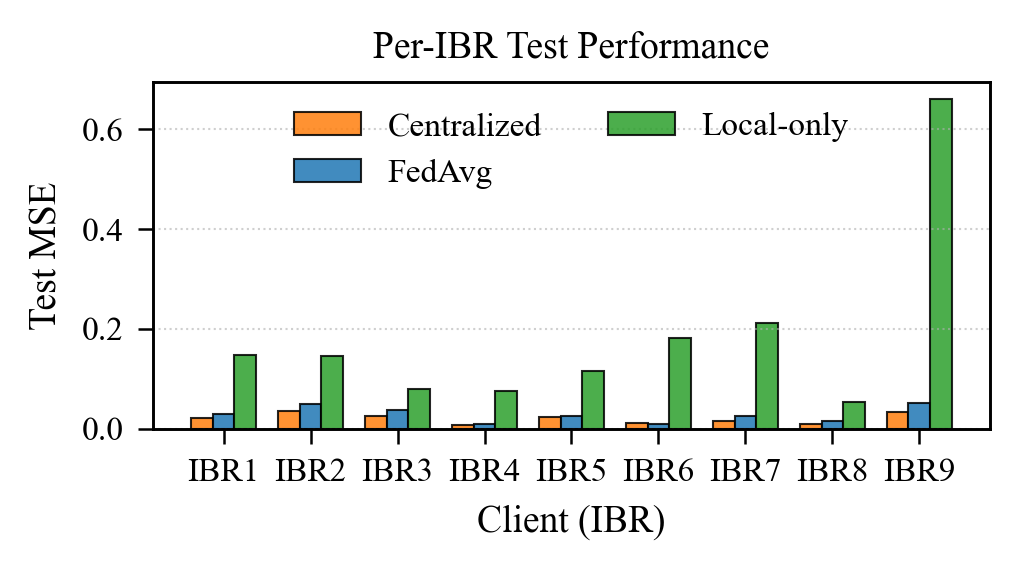

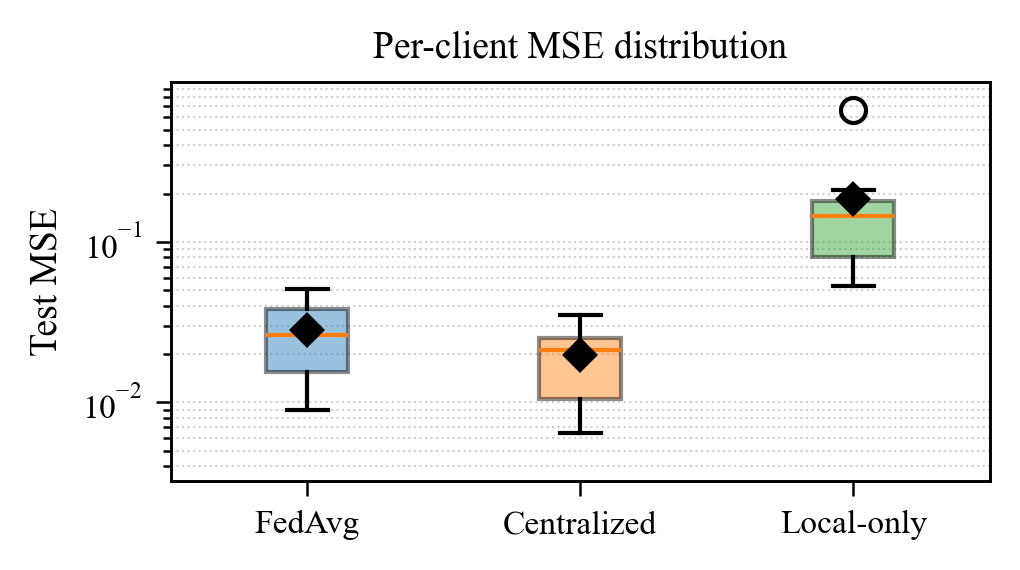

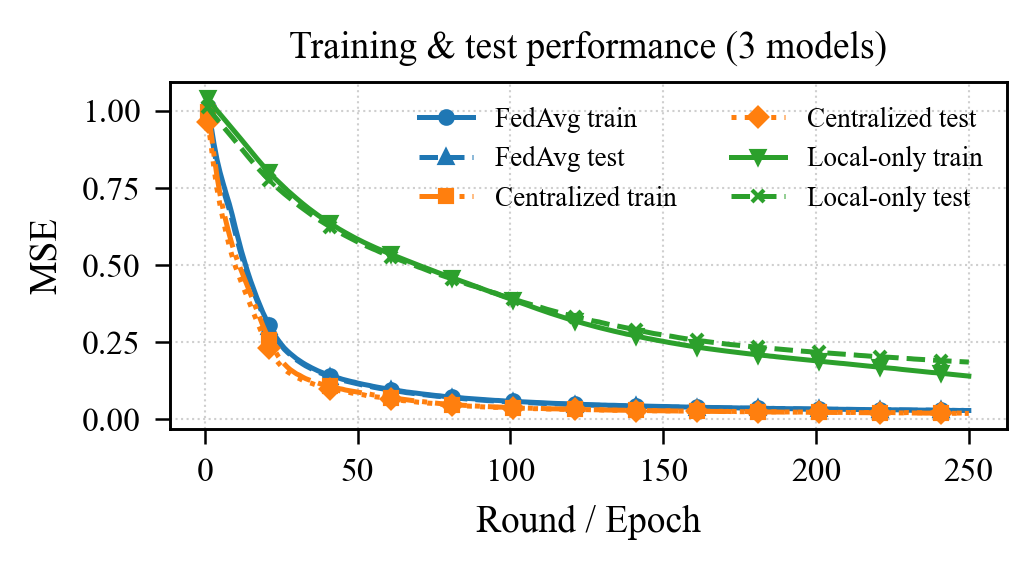

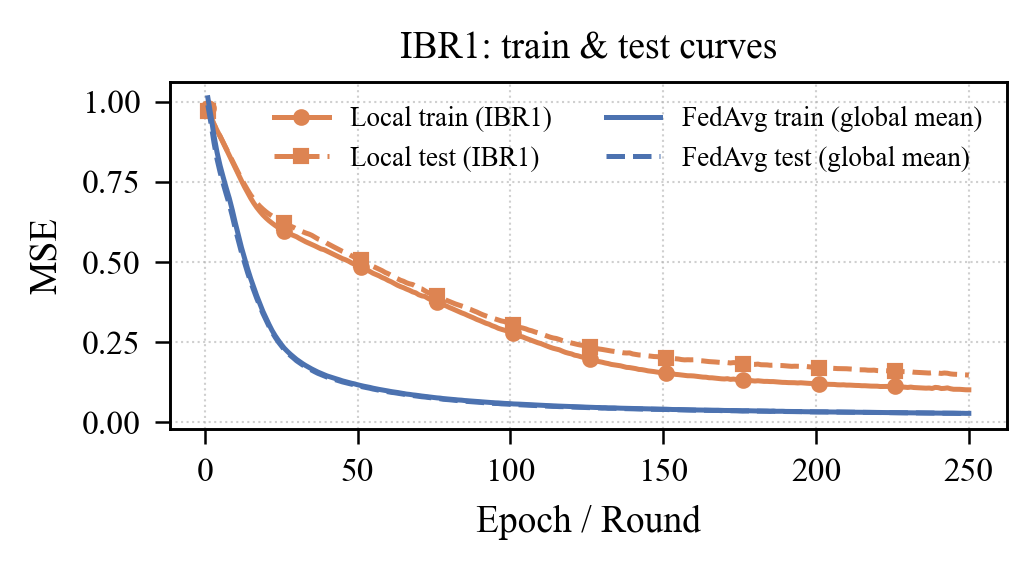

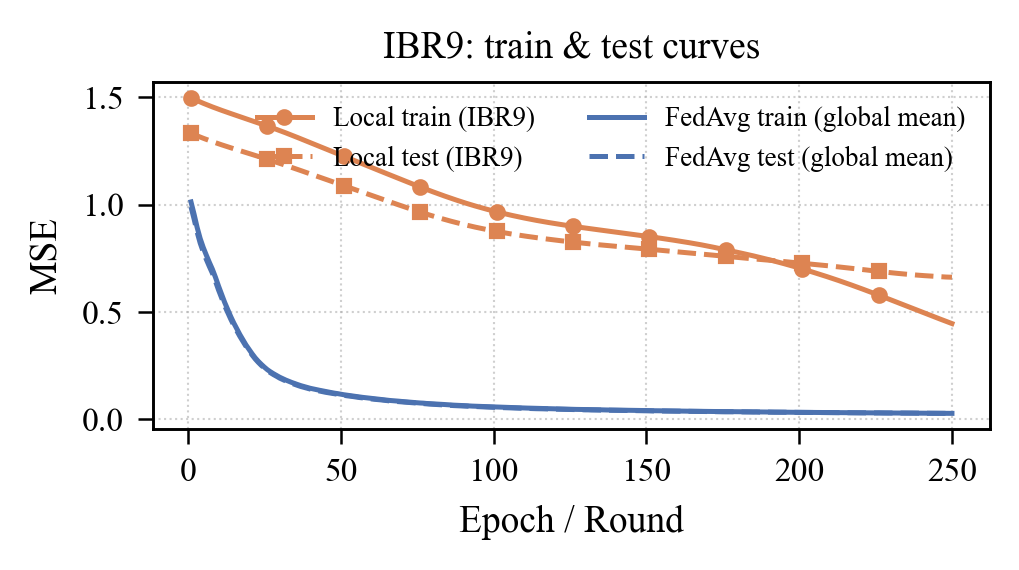

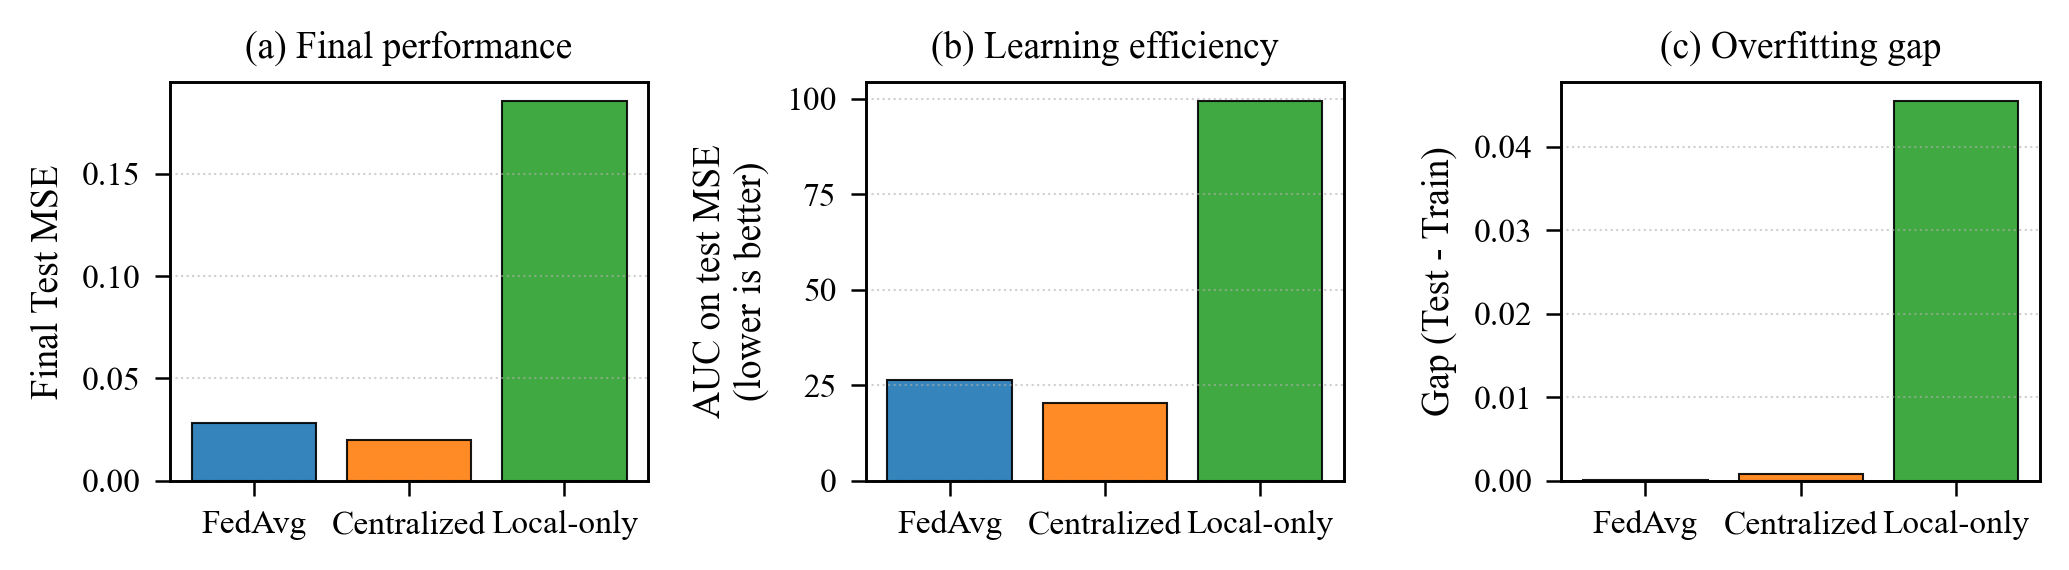

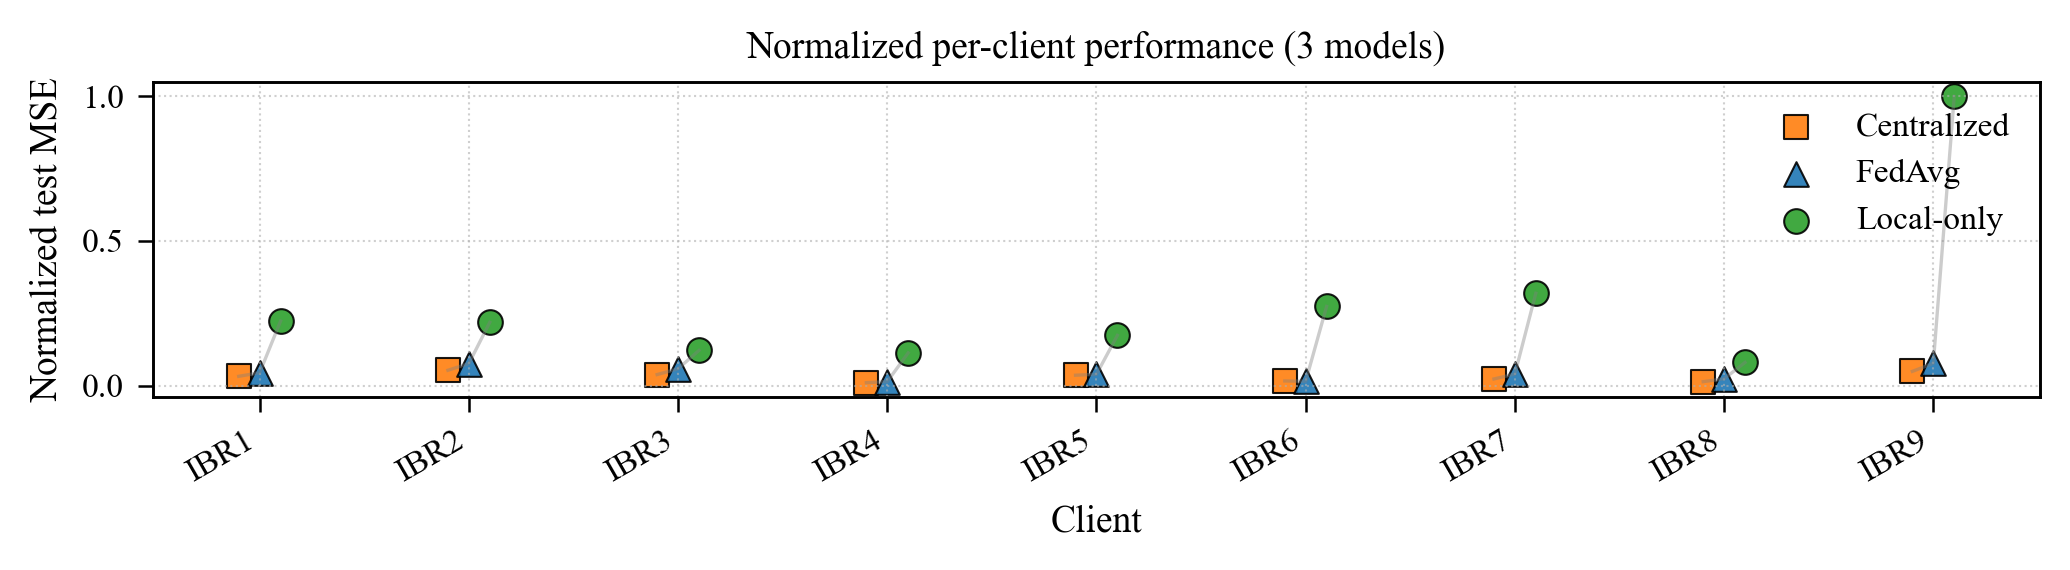

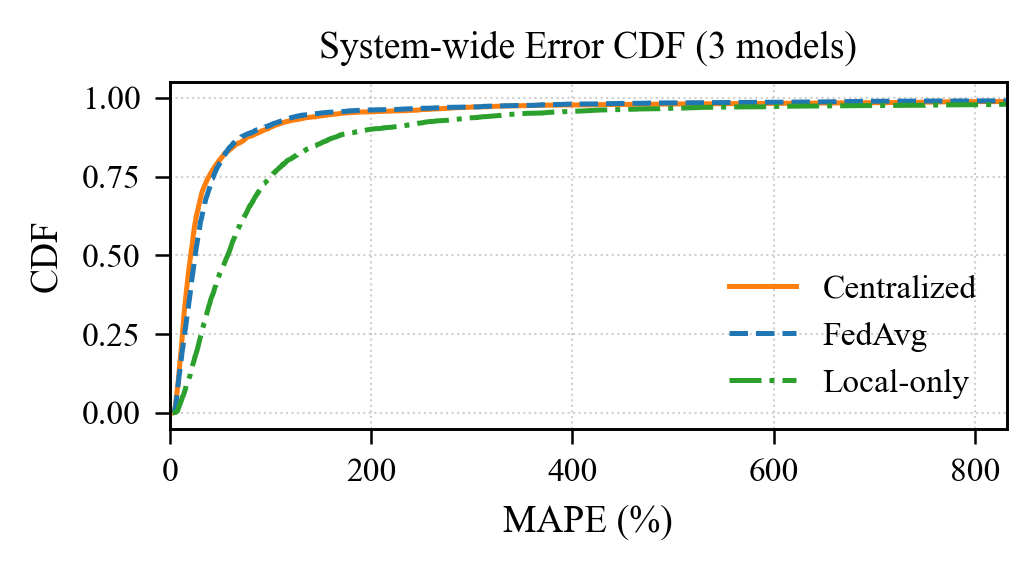

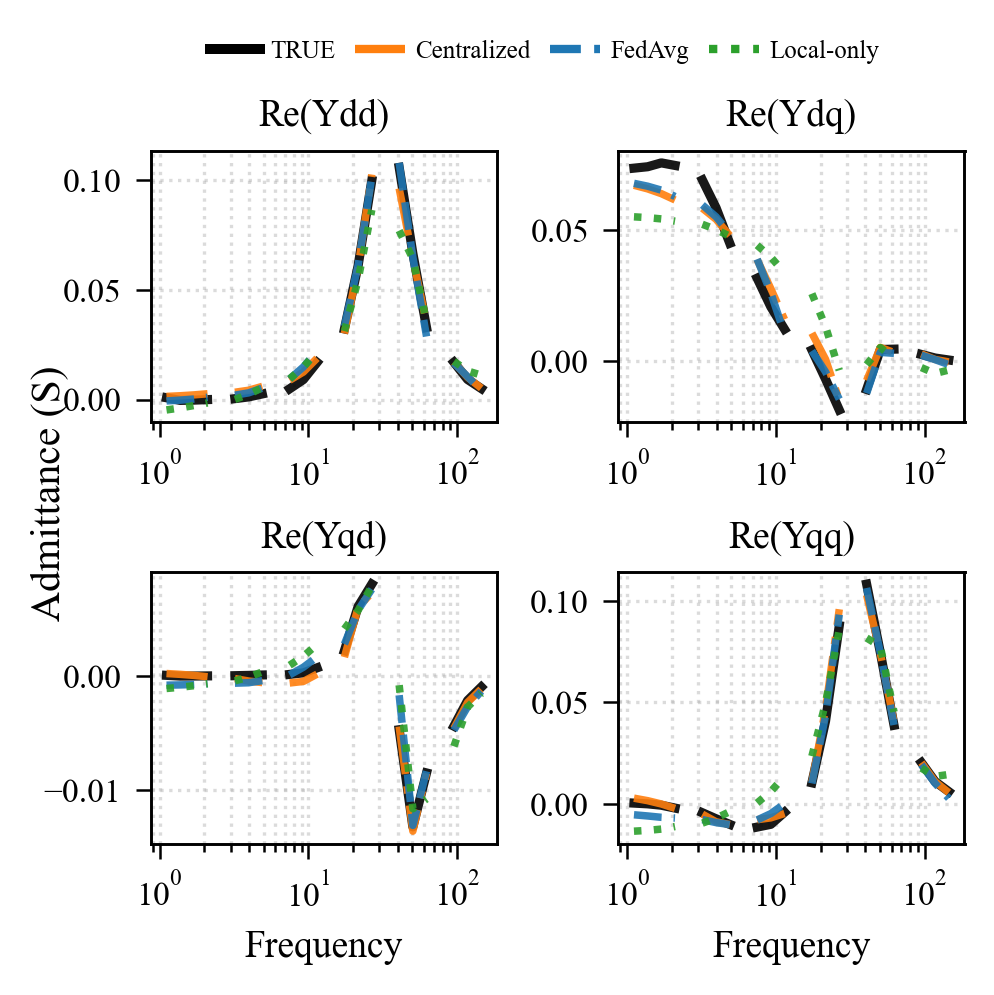

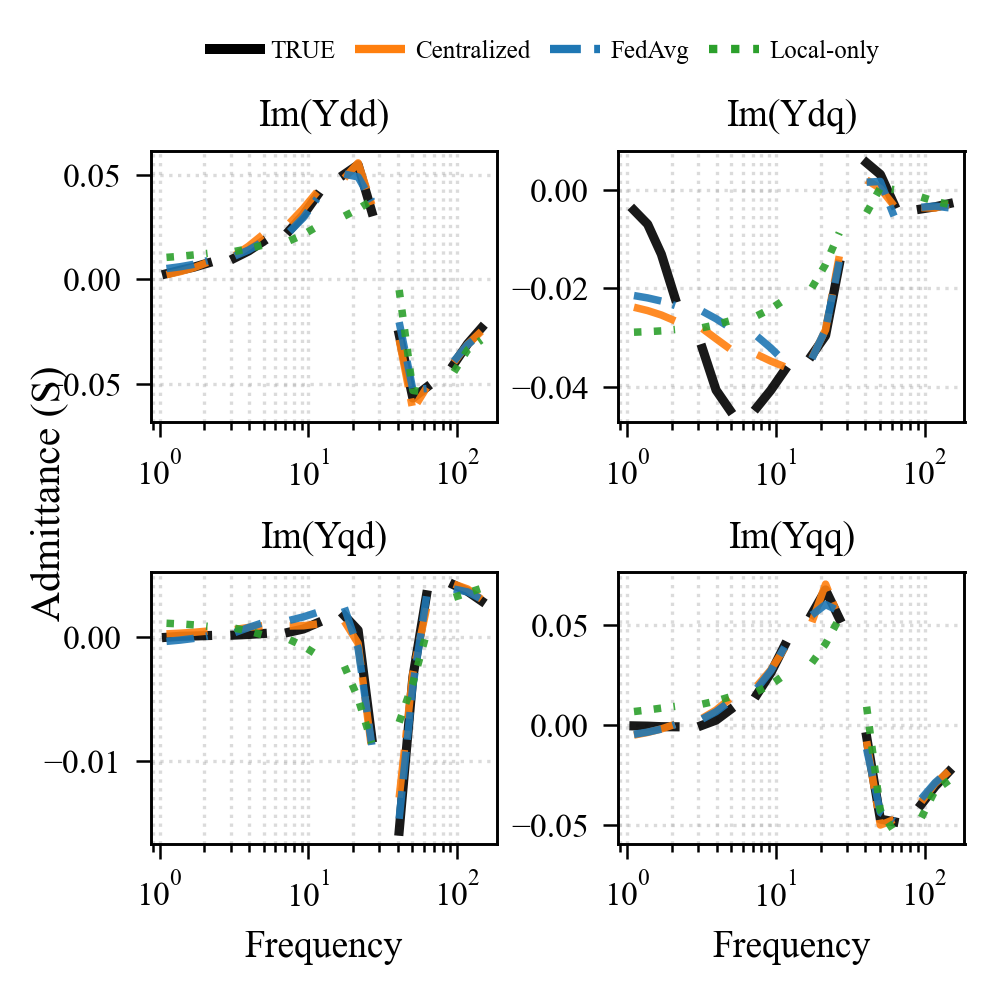

In [13]:
%run -i plot_fl_central_local_combined.py


===== FL vs Local-Only: Training Local Baselines =====

Training local-only models for each client...
--------------------------------------------------
Processing gfli1_impedance_dataset...
  Local: 1.7236e-01 | FedAvg: 2.9277e-02 | Improvement: +83.0%
Processing gfli2_impedance_dataset...
  Local: 1.1776e-01 | FedAvg: 5.0358e-02 | Improvement: +57.2%
Processing gfli3_impedance_dataset...
  Local: 7.5832e-02 | FedAvg: 3.8328e-02 | Improvement: +49.5%
Processing gfli4_impedance_dataset...
  Local: 6.8492e-02 | FedAvg: 8.9973e-03 | Improvement: +86.9%
Processing gfli5_impedance_dataset...
  Local: 1.1277e-01 | FedAvg: 2.5708e-02 | Improvement: +77.2%
Processing gfli6_impedance_dataset...
  Local: 1.4368e-01 | FedAvg: 9.7822e-03 | Improvement: +93.2%
Processing gfli7_impedance_dataset...
  Local: 2.3335e-01 | FedAvg: 2.6337e-02 | Improvement: +88.7%
Processing gfli8_impedance_dataset...
  Local: 5.7120e-02 | FedAvg: 1.5398e-02 | Improvement: +73.0%
Processing gfli9_impedance_dataset...


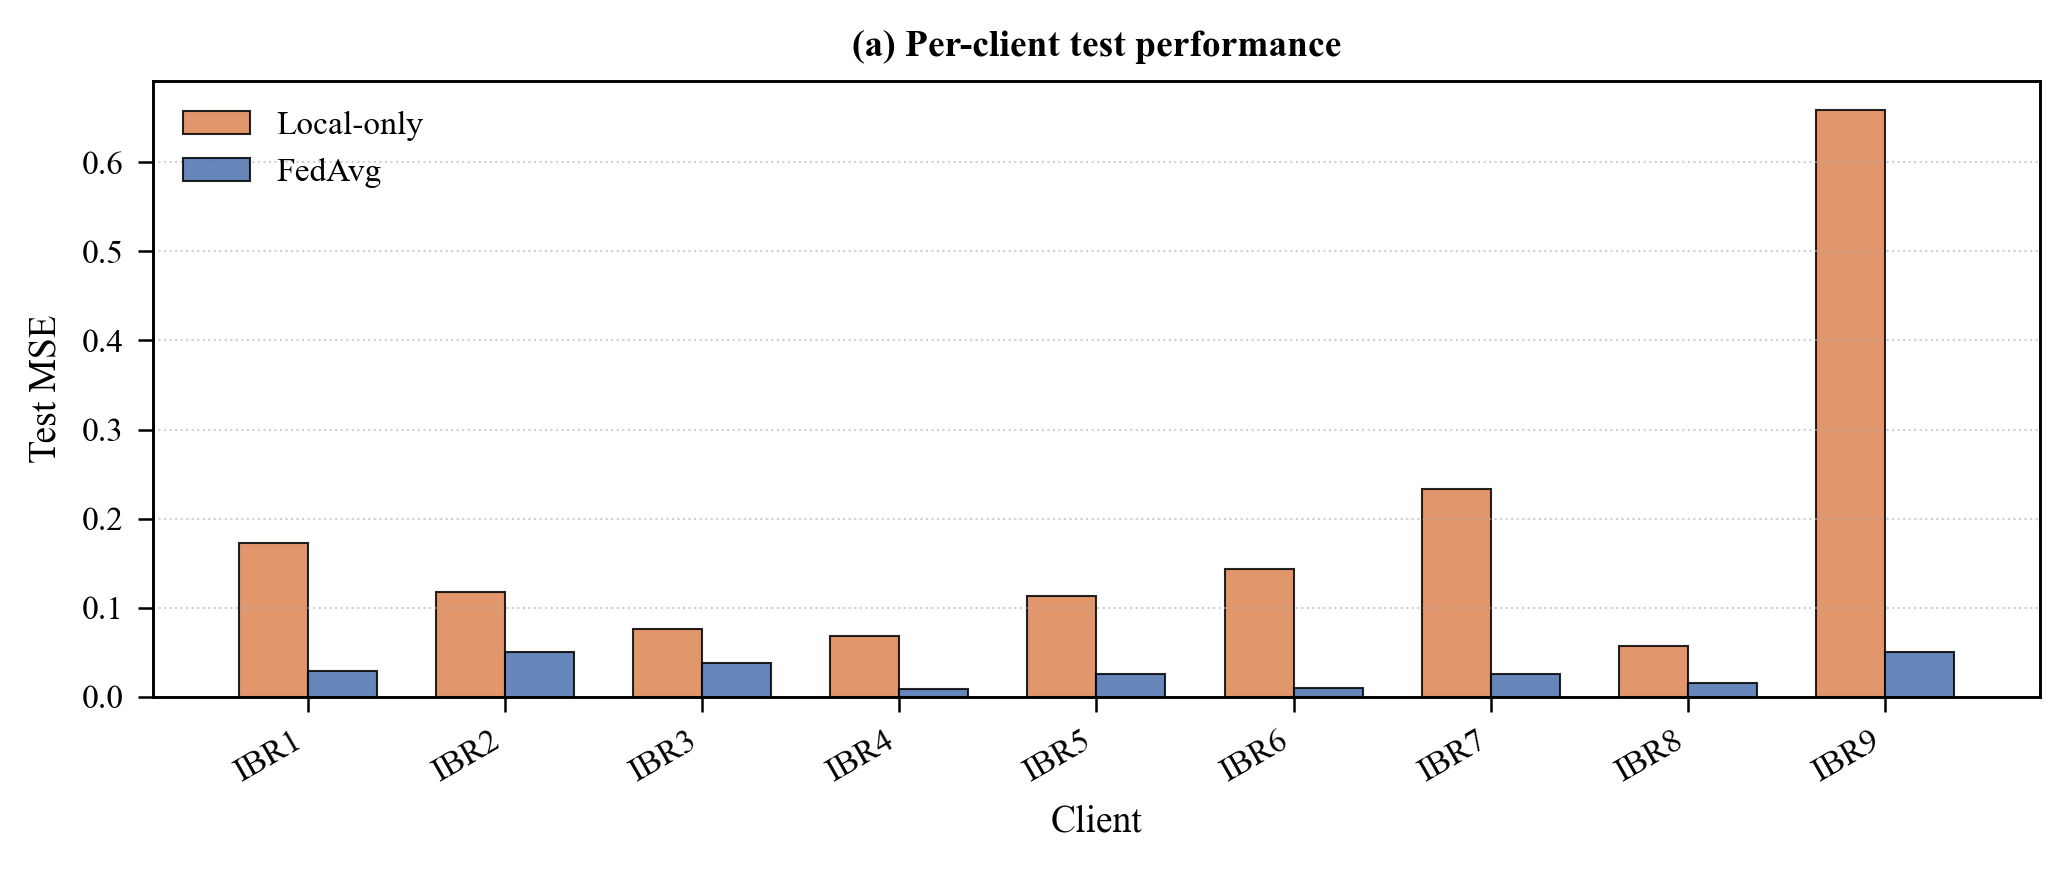

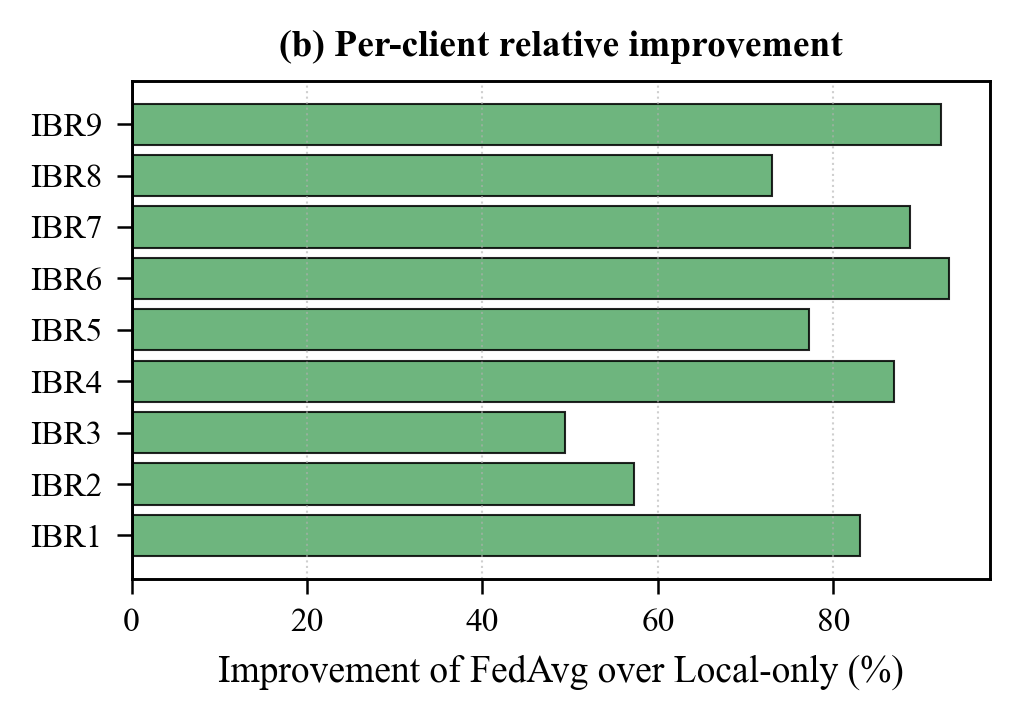

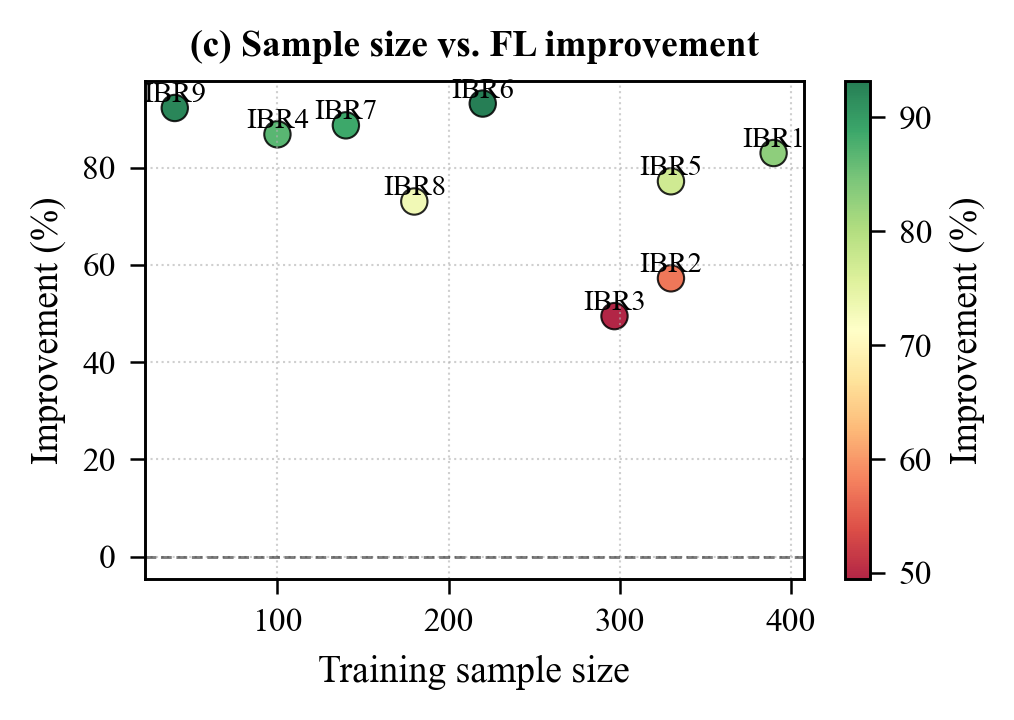

C:\Users\ACER\OneDrive - Umich\My PhD\Research\Topic discussion\Impedance-based Stability Analysis\ML_basedIMEst\FL\CodeImplement\FL_vs_LocalOnly.py:240: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=['FedAvg', 'Local-only'], patch_artist=True, showmeans=True, meanprops=dict(marker='D', markerfacecolor='black', markeredgecolor='black', markersize=5))


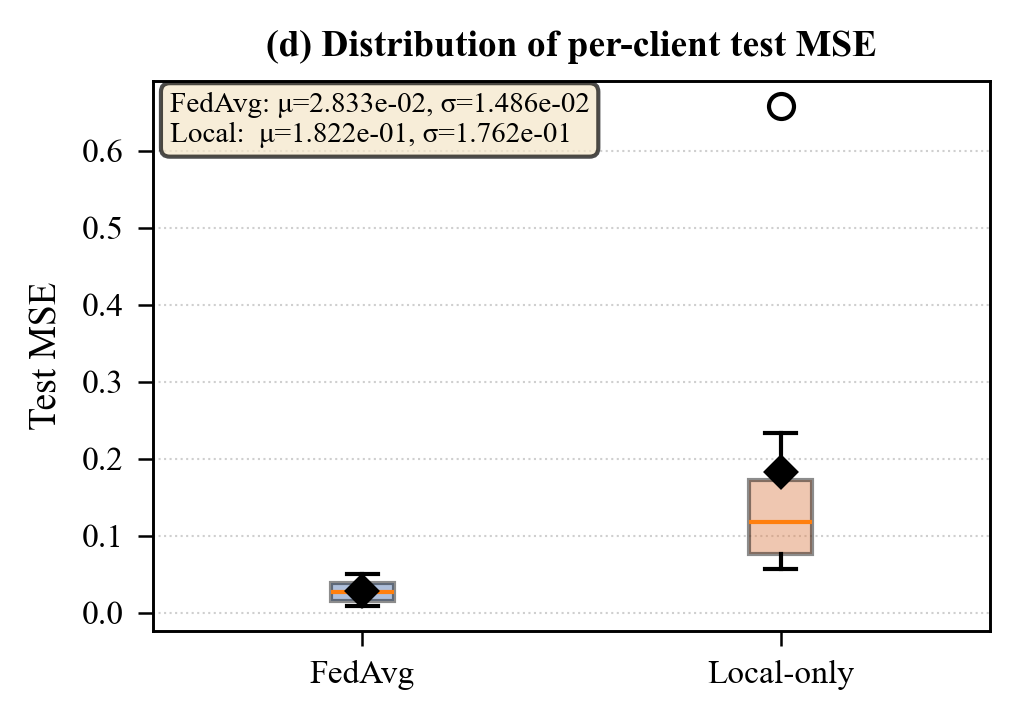

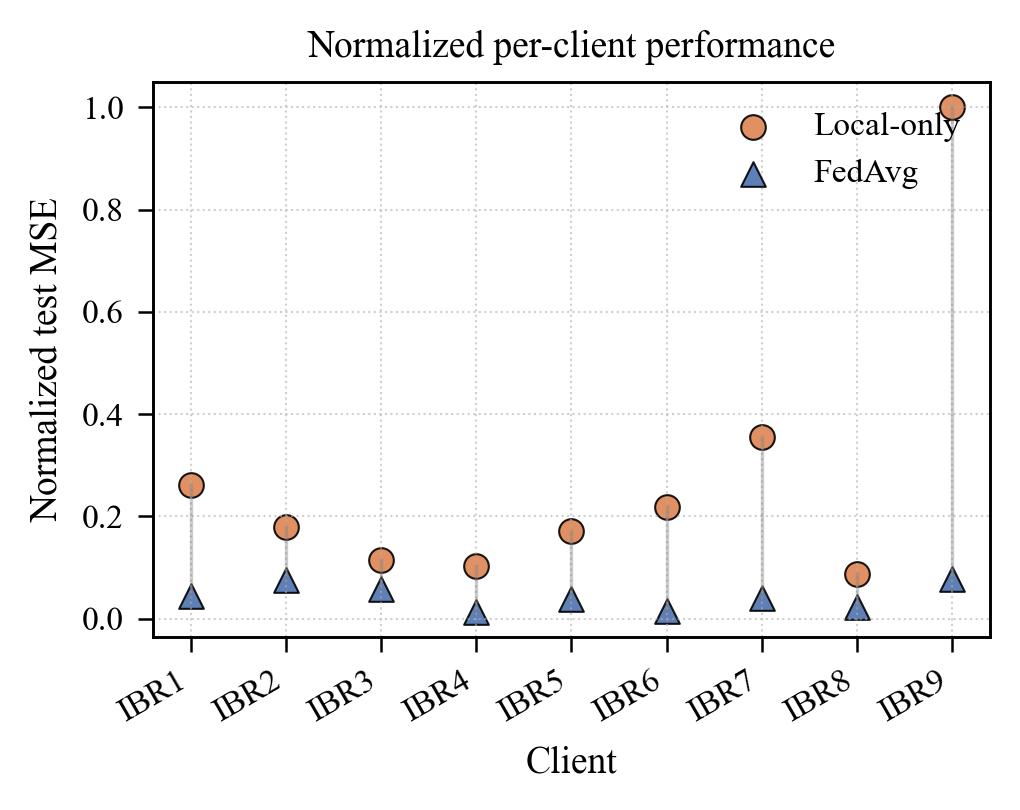

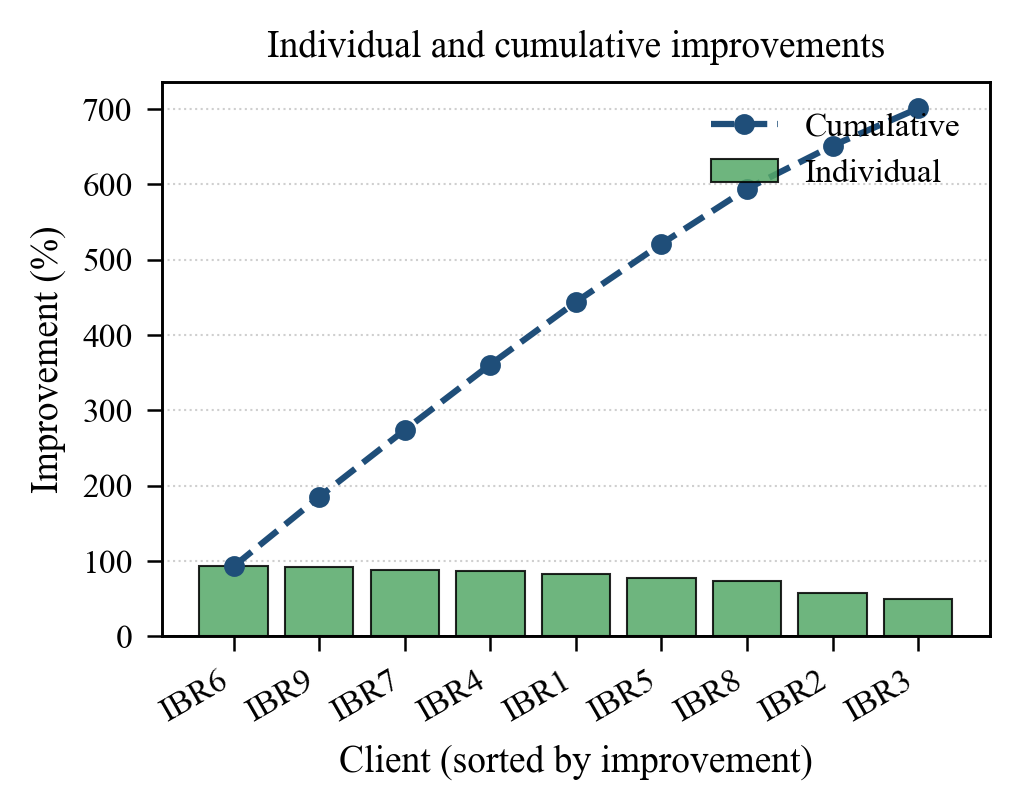


SUMMARY: FL vs Local-only Training
Average Test MSE:
  FedAvg:     0.028331 (σ=0.014857)
  Local-only: 0.182162 (σ=0.176237)
  Overall Improvement: +84.45%

Variance Reduction:
  Std reduction: +91.57%
  ✓ FL reduces variance across clients

Client-Level Analysis:
  Clients improved: 9/9
  Best improvement: +93.19% (IBR6)
  Worst result: +49.46% (IBR3)
  Average improvement: +77.89%

Fairness (performance inequality):
  FedAvg range: 0.041796
  Local range:  0.600977
  ✓ FL improves fairness (+93.0%)


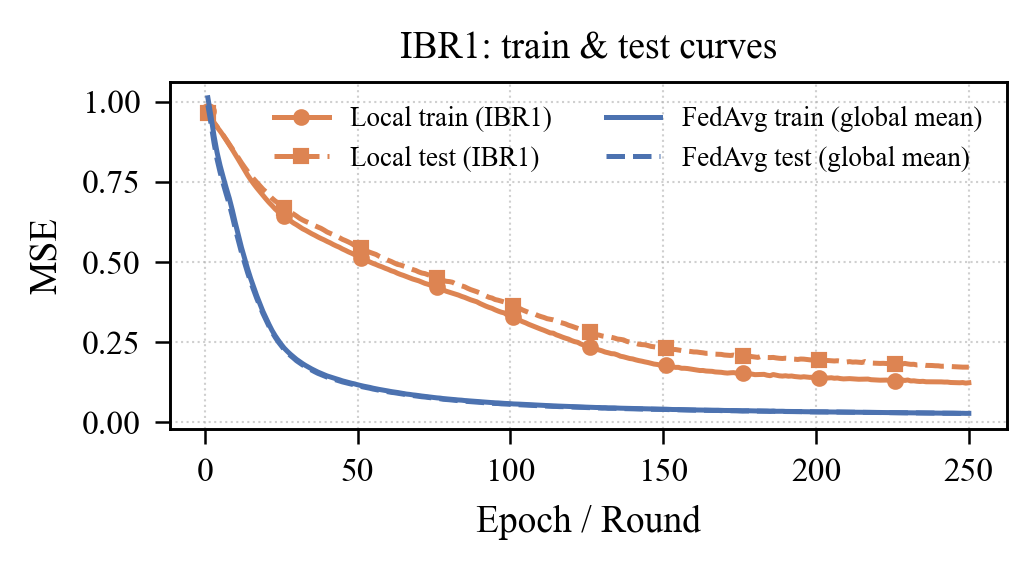

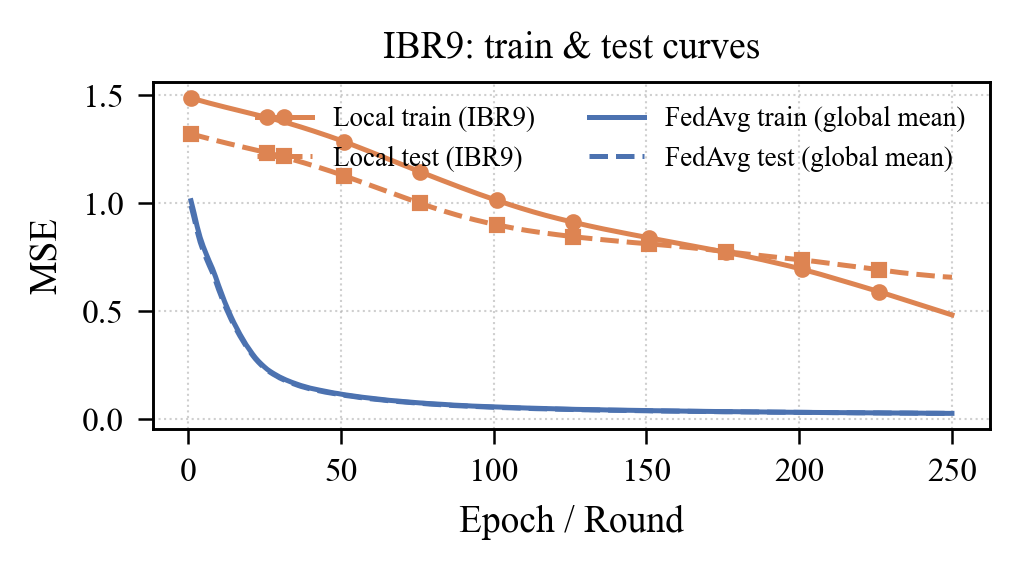

In [ ]:
# %run -i FL_vs_LocalOnly.py